In [41]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [21]:
#cargar datos
df=pd.read_csv('data/listingstTrentino.csv')
#vista previa de los datos
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
0,37736,Charming cozy apartment North Italy,162348,Daniele,NaN,Trentino,46.43561,11.10380,Entire home/apt,159.0,7,116,2024-12-27,0.67,4,345,16,IT022253B566UC9TNJ
1,56292,Central apartment located on the ski slopes,266605,S.,NaN,Trentino,46.23199,10.82732,Entire home/apt,279.0,7,14,2024-12-28,0.15,1,285,5,IT022143C2IU7Z7ICY
2,249351,B&B Casa dei Ricci in the Dolomites,1306234,Maddalena,NaN,Trentino,46.36155,10.91591,Private room,72.0,3,12,2018-08-11,0.08,1,23,0,NaN
3,299464,Residence Segattini Studio 2-3 Persone,1543124,Cristiano,NaN,Trentino,45.90883,10.84660,Entire home/apt,147.0,3,1,2022-01-02,0.03,11,259,0,IT022153B4C5REPYIH
4,367596,"Apartment in Val Rendena, Pinzolo",1854440,Franca,NaN,Trentino,46.15799,10.76669,Entire home/apt,95.0,2,39,2024-12-15,0.27,1,71,5,IT022143C2SDGYRLIZ


In [29]:
df.shape
df.columns
df.dtypes
df.describe()
df.isnull().sum()

id                                   0
name                                 0
host_id                              0
host_name                            0
neighbourhood_group               8514
neighbourhood                        0
latitude                             0
longitude                            0
room_type                            0
price                             1117
minimum_nights                       0
number_of_reviews                    0
last_review                       1827
reviews_per_month                 1827
calculated_host_listings_count       0
availability_365                     0
number_of_reviews_ltm                0
license                           1457
dtype: int64

In [30]:
# Ver todas las columnas disponibles
df.columns.tolist()


['id',
 'name',
 'host_id',
 'host_name',
 'neighbourhood_group',
 'neighbourhood',
 'latitude',
 'longitude',
 'room_type',
 'price',
 'minimum_nights',
 'number_of_reviews',
 'last_review',
 'reviews_per_month',
 'calculated_host_listings_count',
 'availability_365',
 'number_of_reviews_ltm',
 'license']

In [69]:
#renombrado de columnas clave
df = df.rename(columns={
    'price': 'precio',
    'room_type': 'tipo_habitacion',
    'neighbourhood': 'barrio',
    'reviews_per_month': 'puntuacion',
    'number_of_reviews': 'num_resenas',
    'minimum_nights': 'noches_minimas',
    'availability_365': 'disponibilidad_365',
    'host_name': 'es_superanfitrion'
})


In [48]:
#Anlisis de datos

# Ver precios estadísticamente
df['precio'].describe()

# Ver frecuencia de tipos de habitación
df['tipo_habitacion'].value_counts()


tipo_habitacion
Entire home/apt    7475
Private room       1013
Hotel room           24
Shared room           2
Name: count, dtype: int64

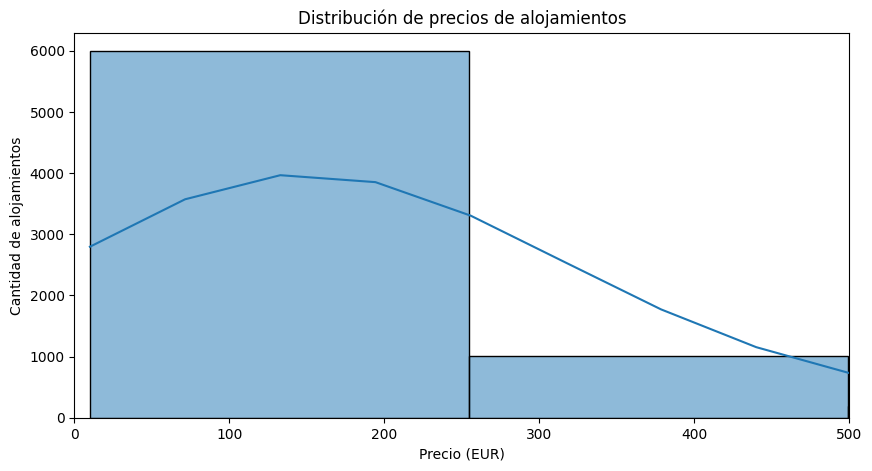

In [50]:
#Distribución de precios

plt.figure(figsize=(10,5))
sns.histplot(df['precio'], bins=50, kde=True)
plt.title('Distribución de precios de alojamientos')
plt.xlabel('Precio (EUR)')
plt.ylabel('Cantidad de alojamientos')
plt.xlim(0, 500)  # Puedes ajustar según valores extremos
plt.show()


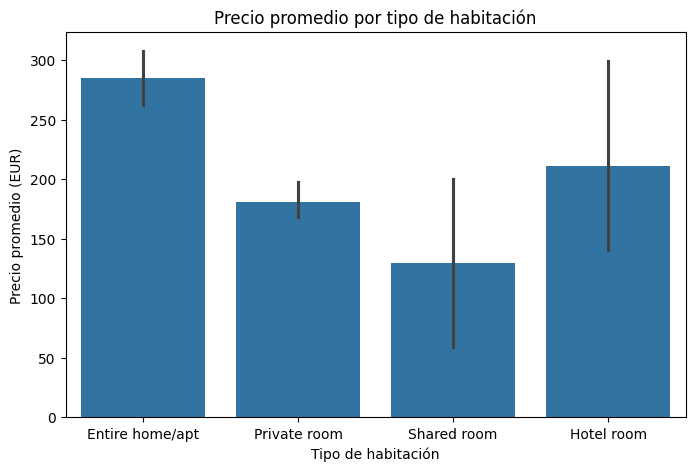

In [51]:
#Precios promedio por tipo de habitación
plt.figure(figsize=(8,5))
sns.barplot(data=df, x='tipo_habitacion', y='precio', estimator='mean')
plt.title('Precio promedio por tipo de habitación')
plt.xlabel('Tipo de habitación')
plt.ylabel('Precio promedio (EUR)')
plt.show()


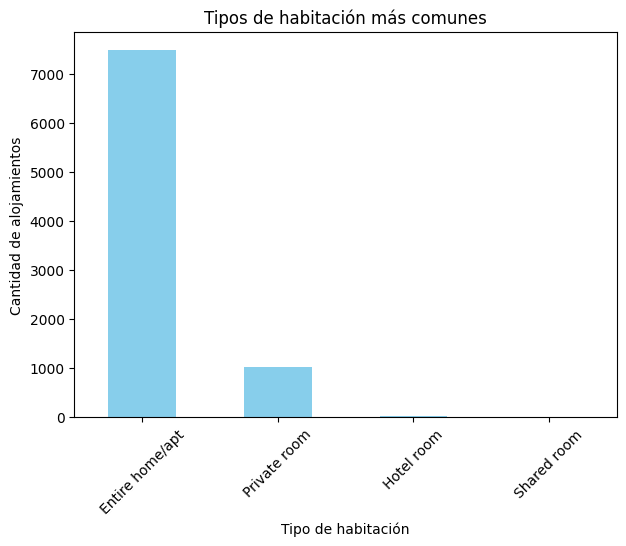

In [71]:
#¿Qué tipo de alojamiento es el más común?
plt.figure(figsize=(7,5))
df['tipo_habitacion'].value_counts().plot(kind='bar', color='skyblue')
plt.title('Tipos de habitación más comunes')
plt.xlabel('Tipo de habitación')
plt.ylabel('Cantidad de alojamientos')
plt.xticks(rotation=45)
plt.show()




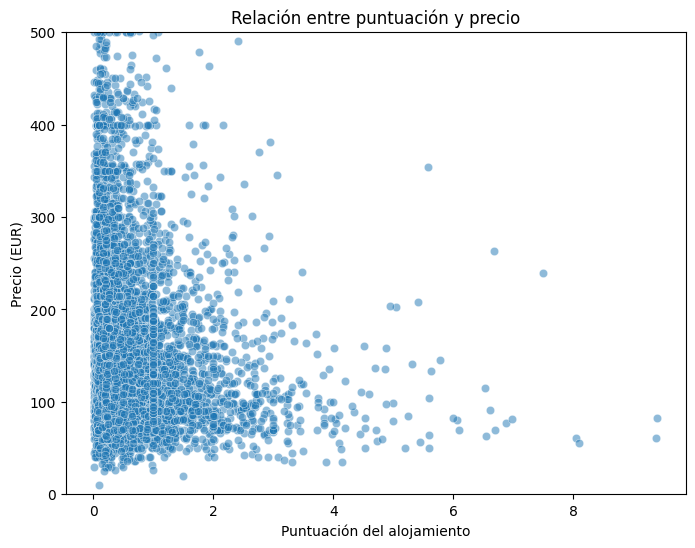

In [73]:
#Relación entre puntuación y precio
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='puntuacion', y='precio', alpha=0.5)
plt.title('Relación entre puntuación y precio')
plt.xlabel('Puntuación del alojamiento')
plt.ylabel('Precio (EUR)')
plt.ylim(0, 500)
plt.show()


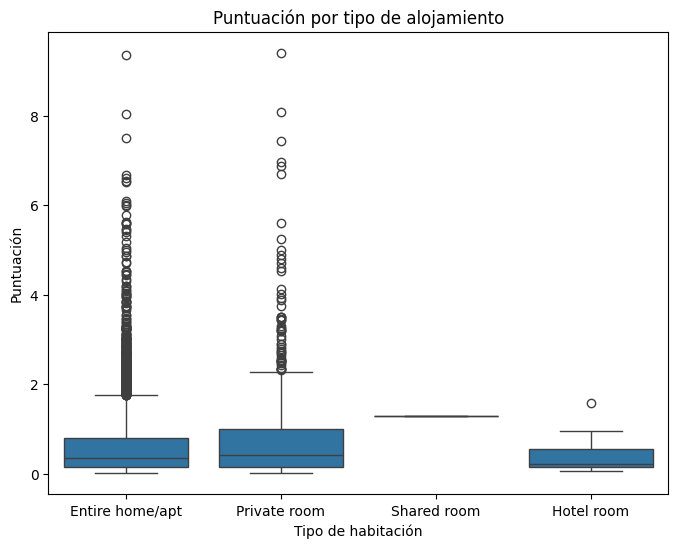

In [74]:
#¿Hay diferencia en puntuación entre tipos de alojamiento?
plt.figure(figsize=(8,6))
sns.boxplot(data=df, x='tipo_habitacion', y='puntuacion')
plt.title('Puntuación por tipo de alojamiento')
plt.xlabel('Tipo de habitación')
plt.ylabel('Puntuación')
plt.show()


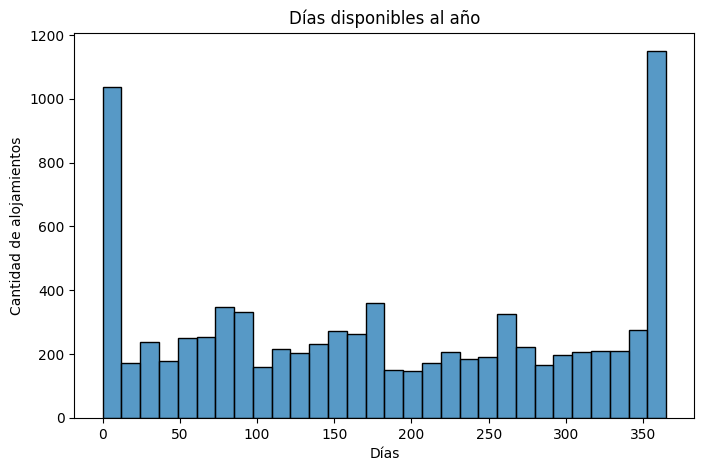

In [75]:
#Disponibilidad de alojamientos
plt.figure(figsize=(8,5))
sns.histplot(df['disponibilidad_365'], bins=30, kde=False)
plt.title('Días disponibles al año')
plt.xlabel('Días')
plt.ylabel('Cantidad de alojamientos')
plt.show()
